# Lesson 05: Order routing and LP execution (fill ratio, last look, partial fills, latency)
**Level:** intermediate → advanced

A-book orders are routed by the bridge to the LP with the best price (IOC limit at the LP's quote). If the LP
rejects or only partially fills, the bridge re-routes the remainder (up to 3 attempts). This lesson rebuilds every
order's lifecycle from the FIX logs and answers the questions an LP review meeting asks:
* Which LP actually fills? Fill ratio, reject reasons, partial fills.
* How long does each LP hold orders, and is its **last look symmetric** (S08)?
* What does a reject *cost* the client, and is the "tightest" LP really the cheapest?
* Did any LP's latency degrade (S07), and did any orders hang (S06)?
* Are we sending the right **quantities** (S10)?

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import analysis as A, plotting as P
P.setup()
pd.set_option("display.width", 200, "display.max_columns", 30)

msgs = A.load_fix_messages()
quotes = A.lp_quotes(msgs)
orders, deals = A.load_platform()
sym, cfg, audit, clients = A.load_reference()
PIP, CONTRACT = sym.pip_size.to_dict(), sym.contract_size.to_dict()

## 1. Order lifecycle table from FIX
One row per **LP order** (ClOrdID): when it was sent, the limit price, the LP's answer, fill quantity and the
round-trip time. ClOrdID `BR<platform order>-<attempt>` links it back to the client order.

In [2]:
d = msgs[msgs.msg_type == "D"][["lp", "cl_ord_id", "log_time", "symbol", "side", "order_qty", "price"]] \
        .rename(columns={"log_time": "sent", "price": "limit"})
er = msgs[(msgs.msg_type == "8") & (msgs.poss_dup != "Y")]
ans = er.groupby("cl_ord_id").agg(answered=("log_time", "min"),
                                  outcome=("exec_type", lambda s: "REJECTED" if "8" in set(s) else ("FILL" if "F" in set(s) else "?")),
                                  filled_qty=("last_qty", "sum"), reason=("text", "first")).reset_index()
life = d.merge(ans, on="cl_ord_id", how="left")
life["outcome"] = life.outcome.fillna("NO ANSWER")
life["rtt_ms"] = (life.answered - life.sent).dt.total_seconds() * 1000
life["partial"] = (life.outcome == "FILL") & (life.filled_qty < life.order_qty - 1e-9)
life["order_id"] = life.cl_ord_id.str.extract(r"BR(\d+)-")[0].astype(int)
life["attempt"] = life.cl_ord_id.str.extract(r"-(\d+)$")[0].astype(int)
life["side"] = life.side.map({"1": "BUY", "2": "SELL"})
life.head()

,lp,cl_ord_id,sent,symbol,side,order_qty,limit,answered,outcome,filled_qty,reason,rtt_ms,partial,order_id,attempt
0,LP_C,BR700004-1,2025-10-15 11:30:34.405,XAUUSD,SELL,9.4,4085.76000,2025-10-15 11:30:34.536,FILL,1.5,IOC remainder cancelled,131.0,True,700004,1
1,LP_A,BR700004-2,2025-10-15 11:30:34.537,XAUUSD,SELL,790.0,4085.73000,2025-10-15 11:30:34.546,FILL,300.0,IOC remainder cancelled,9.0,True,700004,2
2,LP_B,BR700004-3,2025-10-15 11:30:34.547,XAUUSD,SELL,490.0,4085.67000,2025-10-15 11:30:34.585,FILL,200.0,IOC remainder cancelled,38.0,True,700004,3
3,LP_A,BR700005-1,2025-10-15 11:30:43.622,EURUSD,SELL,262000.0,1.16252,2025-10-15 11:30:43.629,FILL,262000.0,NaN,7.0,False,700005,1
4,LP_B,BR700008-1,2025-10-15 11:30:54.745,EURUSD,BUY,94000.0,1.16256,2025-10-15 11:30:54.783,FILL,94000.0,NaN,38.0,False,700008,1


## 2. LP scorecard (first look)

In [3]:
score = life.groupby("lp").agg(orders=("cl_ord_id", "size"),
                               fill_ratio_pct=("outcome", lambda s: 100 * (s == "FILL").mean()),
                               reject_pct=("outcome", lambda s: 100 * (s == "REJECTED").mean()),
                               partial_pct=("partial", lambda s: 100 * s.mean()),
                               no_answer=("outcome", lambda s: (s == "NO ANSWER").sum()),
                               median_rtt_ms=("rtt_ms", "median"), p95_rtt_ms=("rtt_ms", lambda s: s.quantile(.95)))
score.round(1)

,orders,fill_ratio_pct,reject_pct,partial_pct,no_answer,median_rtt_ms,p95_rtt_ms
lp,,,,,,,
LP_A,390,99.7,0.3,11.0,0,7.0,410.1
LP_B,142,83.8,16.2,17.6,0,39.0,43.0
LP_C,331,71.3,27.8,16.6,3,133.0,158.0


In [4]:
life[life.outcome == "REJECTED"].groupby(["lp", "reason"]).size().rename("rejects").reset_index()

,lp,reason,rejects
0,LP_A,Internal error,1
1,LP_B,Price moved,23
2,LP_C,Off quotes,92


LP_C rejects far more than the others ("Off quotes"), and its round trip is ~130 ms against ~7 ms at LP_A. That
long round trip is LP_C's **last-look hold**: it keeps each order ~120 ms before deciding.

## 3. Is the last look symmetric? (S08)
Between the moment the LP quoted a price and the moment it decides, the market moves. A **fair** last look rejects
when the price moved too much **either** way. An **asymmetric** one rejects only when the move favours the client
(so the LP would lose), and happily fills when the move favours itself.

**Test:** for every order, estimate the LP's price at decision time from the market shortly after its answer
(consensus mid at answer + 300 ms, ± the LP's typical half-spread). Compare it with the limit price the order was
sent at:
* `move > 0`: the market moved **in the client's favour** (the LP would fill at a now-cheap price)
* `move < 0`: the market moved **in the LP's favour**

The move is expressed in units of the LP's half-spread so the three symbols can be pooled. The S02 window is
excluded because those rejects were caused by a stale feed, not by last-look policy.

In [5]:
mid = {s: A.mid_series(quotes, s) for s in sym.index}                    # robust consensus mid per symbol
half = (quotes.assign(sp=quotes.ask1 - quotes.bid1).groupby(["lp", "symbol"]).sp.median() / 2)
life["mid_after"] = np.nan
for s in sym.index:
    m = (life.symbol == s) & life.answered.notna()
    life.loc[m, "mid_after"] = A.value_at(mid[s], life.loc[m, "answered"] + pd.Timedelta(milliseconds=300))
sgn = np.where(life.side == "BUY", 1, -1)
hs = np.array([half.get((l, s), np.nan) for l, s in zip(life.lp, life.symbol)])
life["move_client"] = (life.mid_after + sgn * hs - life.limit) * sgn / hs           # in half-spreads
ll = life[life.outcome.isin(["FILL", "REJECTED"]) &
          ~life.sent.between("2025-10-15 12:05:00", "2025-10-15 12:06:30")].copy()
ll["move_bucket"] = pd.cut(ll.move_client, [-99, -1, -0.25, 0.25, 1, 99],
                           labels=["< -1 (LP favoured)", "-1..-0.25", "~0", "0.25..1", "> 1 (client favoured)"])
table = ll.pivot_table(index="move_bucket", columns="lp", values="outcome", observed=False,
                       aggfunc=lambda s: round(100 * (s == "REJECTED").mean(), 1))
counts = ll.pivot_table(index="move_bucket", columns="lp", values="outcome", aggfunc="size", observed=False)
print("Reject rate % by market move between quote and decision (orders per bucket in *_n)")
table.join(counts, rsuffix="_n")

Reject rate % by market move between quote and decision (orders per bucket in *_n)


lp,LP_A,LP_B,LP_C,LP_A_n,LP_B_n,LP_C_n
move_bucket,,,,,,
< -1 (LP favoured),0.0,30.0,19.0,23,10,21
-1..-0.25,4.2,0.0,0.0,24,7,15
~0,0.0,0.0,12.2,190,50,148
0.25..1,0.0,3.8,37.8,125,52,111
> 1 (client favoured),0.0,40.0,100.0,9,5,14


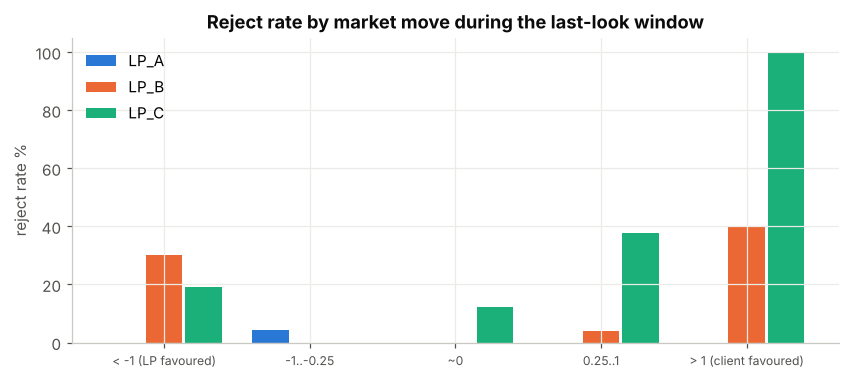

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(table.index))
for i, lp in enumerate(A.LPS):
    ax.bar(x + (i - 1) * 0.27, table[lp].fillna(0), width=0.25, color=P.LP_COLORS[lp], label=lp)
ax.set_xticks(x, table.index, fontsize=8)
ax.set_ylabel("reject rate %"); ax.set_title("Reject rate by market move during the last-look window")
ax.legend(); plt.show()

In [7]:
rej = ll[ll.outcome == "REJECTED"]
fil = ll[ll.outcome == "FILL"]
pd.DataFrame({"rejects": rej.groupby("lp").size(),
              "% of rejects when market moved in client's favour": (rej.move_client > 0).groupby(rej.lp).mean().mul(100).round(0),
              "% of fills when market moved in LP's favour": (fil.move_client < 0).groupby(fil.lp).mean().mul(100).round(0)})

,rejects,% of rejects when market moved in client's favour,% of fills when market moved in LP's favour
lp,,,
LP_A,1,0.0,26.0
LP_B,7,57.0,26.0
LP_C,79,91.0,32.0


**Verdict:**
* **LP_A:** practically never rejects (firm liquidity).
* **LP_B:** rejects mostly the **large** moves, in **both** directions. That's consistent with a symmetric
  price-tolerance check. Small sample, so keep monitoring.
* **LP_C:** its reject rate climbs steadily as the move turns in the **client's** favour, and the great majority of its
  rejects happen when the client would have won. That's the signature of **asymmetric last look**, which the FX Global
  Code (Principle 17) says is not acceptable.

**Action:** raise it with LP_C (ask for their last-look policy and hold-time stats), reduce LP_C's routing weight,
or move to firm liquidity only.

## 4. What does a reject cost? (Is the "tightest" LP really the cheapest?)
When an LP rejects, the bridge re-routes, usually at a **worse** price. Compare the first limit price (what the
router expected to pay) with the final average fill price, per **first-choice LP**.

In [8]:
first = life[life.attempt == 1][["order_id", "lp", "symbol", "side", "limit"]].rename(columns={"lp": "first_lp", "limit": "first_limit"})
fills = er[er.exec_type == "F"].assign(order_id=lambda x: x.cl_ord_id.str.extract(r"BR(\d+)-")[0].astype(int))
vwap = (fills.assign(px_qty=fills.last_px * fills.last_qty).groupby("order_id")
        .agg(px_qty=("px_qty", "sum"), qty=("last_qty", "sum")))
vwap["lp_vwap"] = vwap.px_qty / vwap.qty                                   # average LP price actually paid
cl_mk = first.merge(vwap.lp_vwap.reset_index(), on="order_id")
cl_mk["reroute_cost_pips"] = (cl_mk.lp_vwap - cl_mk.first_limit) * np.where(cl_mk.side == "BUY", 1, -1) / cl_mk.symbol.map(PIP)
cost = cl_mk[cl_mk.symbol != "XAUUSD"].groupby("first_lp").reroute_cost_pips.agg(["count", "mean", "median"]).round(3)
cost

,count,mean,median
first_lp,,,
LP_A,192,0.000,0.0
LP_B,42,0.005,-0.0
LP_C,174,0.323,0.0


In [9]:
adv = []
for s in ["EURUSD", "GBPUSD"]:
    spr = quotes[quotes.symbol == s].assign(sp=lambda q: (q.ask1 - q.bid1) / PIP[s]).groupby("lp").sp.median()
    adv.append(spr.rename(s))
spreads = pd.concat(adv, axis=1)
print("Median quoted spread (pips):"); print(spreads)
print("\nLP_C half-spread advantage vs LP_A (pips, per side):", ((spreads.loc["LP_A"] - spreads.loc["LP_C"]) / 2).round(2).to_dict())
print("Average re-route cost when LP_C was first choice (pips):", cost.loc["LP_C", "mean"])

Median quoted spread (pips):
      EURUSD  GBPUSD
lp                  
LP_A     0.4     0.7
LP_B     0.5     0.8
LP_C     0.3     0.6

LP_C half-spread advantage vs LP_A (pips, per side): {'EURUSD': 0.05, 'GBPUSD': 0.05}
Average re-route cost when LP_C was first choice (pips): 0.323


LP_C *looks* ~0.05 pips better per side, but orders first sent to LP_C end up costing **more** on average once
rejects and re-routes are counted. And the cost isn't random: rejects happen exactly when the market moved in the
client's favour, so the client always pays the move.

**Better routing:** rank LPs on **expected cost**, not quoted price. A simple version:
```
expected_price = quoted_price + reject_probability × average_cost_after_reject
```
With LP_C's reject rate this adds more than its quoted advantage, so LP_A should win most ties.

## 5. Partial fills and liquidity sweeps
Orders bigger than an LP's top-of-book size get partially filled (`39=1`), with the remainder cancelled (IOC) and
re-routed. How often, and for which order sizes?

In [10]:
po = orders[orders.book == "A"].merge(life.groupby("order_id").agg(lp_orders=("cl_ord_id", "size"),
                                                                   partials=("partial", "sum")).reset_index(), on="order_id")
po["size_bucket"] = pd.cut(po.lots, [0, 1, 5, 10, 20, 100], labels=["<=1", "1-5", "5-10", "10-20", ">20"])
po.groupby(["symbol", "size_bucket"], observed=True).agg(orders=("order_id", "size"), avg_lp_orders=("lp_orders", "mean"),
                                                         pct_with_partial=("partials", lambda s: 100 * (s > 0).mean()),
                                                         pct_not_fully_filled=("status", lambda s: 100 * (s == "PARTIAL").mean())).round(1)

orders  avg_lp_orders  pct_with_partial  pct_not_fully_filled
symbol size_bucket                                                               
EURUSD <=1             146            1.1               0.0                   0.0
       1-5             120            1.1               0.0                   0.0
       5-10             35            1.1               2.9                   0.0
       10-20             2            2.0              50.0                   0.0
GBPUSD <=1              51            1.1               0.0                   0.0
       1-5              49            1.1               0.0                   0.0
       5-10              2            1.0               0.0                   0.0
       10-20             3            2.0              66.7                  33.3
XAUUSD <=1              98            1.2               3.1                   0.0
       1-5             121            1.8              44.6                  11.6
       5-10             23            3.0              95.7                  47.8
       10-20             1            3.0             100.0                 100.0

Large orders (gold especially: LP top-of-book sizes are only 100–300 oz) sweep several LPs and sometimes can't be
filled completely within 3 attempts, so the client gets a **partial fill**. Options: allow more attempts, route
large orders with an **order-splitting** algorithm (send child orders to several LPs at once), or set a maximum
order size per symbol that matches available liquidity.

## 6. Latency: did any LP degrade? (S07)

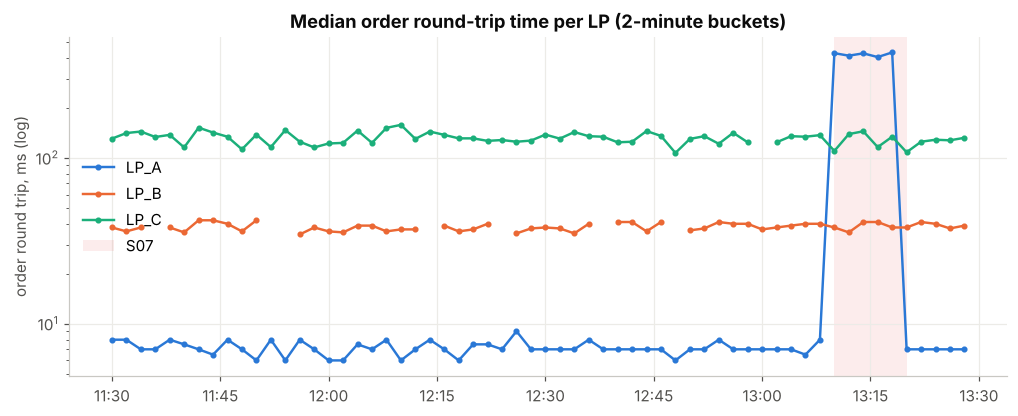

In [11]:
fig, ax = plt.subplots()
for lp in A.LPS:
    g = life[(life.lp == lp) & life.rtt_ms.notna()].set_index("sent").rtt_ms
    r = g.resample("2min").median()
    ax.plot(r.index, r.values, color=P.LP_COLORS[lp], label=lp, marker="o", ms=3)
P.shade(ax, "2025-10-15 13:10", "2025-10-15 13:20", "S07")
ax.set_yscale("log"); ax.set_ylabel("order round trip, ms (log)")
ax.set_title("Median order round-trip time per LP (2-minute buckets)"); P.time_axis(ax); ax.legend(); plt.show()

In [12]:
lpa = life[life.lp == "LP_A"].set_index("sent").rtt_ms
print("LP_A round trip, median by period (ms):")
print(pd.Series({"before 13:10": lpa[:"2025-10-15 13:09:59"].median(),
                 "13:10-13:20": lpa["2025-10-15 13:10":"2025-10-15 13:19:59"].median(),
                 "after 13:20": lpa["2025-10-15 13:20":].median()}).round(1))

LP_A round trip, median by period (ms):
before 13:10      7.0
13:10-13:20     416.5
after 13:20       7.0
dtype: float64


LP_A went from ~7 ms to **~400 ms** for ten minutes and then recovered. Its market data latency (Lesson 02)
didn't change, so the problem is on the **order path**: LP_A's order gateway or the network route to it.
During that window LP_A's "firm" fills were done at prices up to ~400 ms old. Lesson 06 shows who pays for that delay.

## 7. Orders that never got an answer (S06)

In [13]:
life[life.outcome == "NO ANSWER"][["lp", "cl_ord_id", "sent", "symbol", "side", "order_qty", "limit"]] \
    .merge(orders[["order_id", "client_id", "status", "reject_reason"]],
           left_on=life[life.outcome == "NO ANSWER"].order_id, right_on="order_id")

,lp,cl_ord_id,sent,symbol,side,order_qty,limit,order_id,client_id,status,reject_reason
0,LP_C,BR701128-1,2025-10-15 12:59:59.953,XAUUSD,SELL,3.00,4096.8,701128,C1003,REJECTED,LP timeout
1,LP_C,BR701129-1,2025-10-15 13:00:07.278,XAUUSD,SELL,0.29,4096.8,701129,C1001,REJECTED,LP timeout
2,LP_C,BR701131-1,2025-10-15 13:00:15.745,XAUUSD,SELL,0.28,4096.8,701131,C1028,REJECTED,LP timeout


Three orders went to LP_C just before and during its silent period (12:59:59–13:00:22, before the bridge dropped the session). The
bridge waited 1 s, then rejected the clients with *"LP timeout"* and did **not** re-route. That is the correct choice,
because the order's status at the LP was unknown: re-routing could double the position.

But **was any of them executed at LP_C?** An unanswered order is an *unknown*, not a *reject*. Lesson 07 checks
LP_C's trade statement.

## 8. Are we sending the right quantity? (S10)
Each LP has a quantity convention: FX in units of currency, gold in **ounces** (1 lot = 100 oz). Compare the
quantity on the FIX order with the client lots it represents.

In [14]:
lots = orders.set_index("order_id").lots
q = life[life.attempt == 1].copy()
q["client_lots"] = q.order_id.map(lots)
q["qty_per_lot"] = q.order_qty / q.client_lots
q.groupby(["lp", "symbol"]).qty_per_lot.agg(["count", "median", "min", "max"]).round(1)

count    median       min       max
lp   symbol                                     
LP_A EURUSD    144  100000.0  100000.0  100000.0
     GBPUSD     48  100000.0  100000.0  100000.0
     XAUUSD     66     100.0     100.0     100.0
LP_B EURUSD     25  100000.0  100000.0  100000.0
     GBPUSD     17  100000.0  100000.0  100000.0
     XAUUSD     48     100.0     100.0     100.0
LP_C EURUSD    134  100000.0  100000.0  100000.0
     GBPUSD     40  100000.0  100000.0  100000.0
     XAUUSD    129       1.0       1.0       1.0

In [15]:
print("Configured multipliers:", {k: v for k, v in cfg["lp_quantity_multiplier"].items() if "XAU" in k})
audit

Configured multipliers: {'LP_A:XAUUSD': 100, 'LP_B:XAUUSD': 100, 'LP_C:XAUUSD': 1}


,time,user,object,change,ticket
0,2025-10-14 16:20:05.000,admin,LP_C session,lp_quantity_multiplier XAUUSD set to 1,CHG-2291 (new LP onboarding)
1,2025-10-15 12:39:56.800,dealer2,Group STD / GBPUSD,markup 0.8 -> 8.0 pips,none
2,2025-10-15 13:00:00.400,dealer1,Group STD / GBPUSD,markup 8.0 -> 0.8 pips,INC-5521 client complaints


**S10 found:** every LP receives 100 oz per lot of gold **except LP_C, which receives 1 oz per lot**. The bridge
config confirms `LP_C:XAUUSD = 1`, set during LP_C's onboarding (audit log, CHG-2291).

**Impact:** every A-book gold trade routed to LP_C is only **1% hedged**. The platform books the client's full size
while the LP executes 1/100 of it, so the broker carries ~99% of that exposure unhedged without knowing it. Lesson
07 quantifies the position break.

**Fix:** correct the multiplier; add a pre-trade check (LP qty ÷ client lots must equal the contract size) and a
daily position reconciliation per LP.

## LP review summary

In [16]:
summary = score.copy()
summary["reject_%_when_client_favoured"] = table.loc["> 1 (client favoured)"]
summary["reject_%_when_LP_favoured"] = table.loc["< -1 (LP favoured)"]
summary["avg_reroute_cost_pips_fx"] = cost["mean"]
summary.round(1)

,orders,fill_ratio_pct,reject_pct,partial_pct,no_answer,median_rtt_ms,p95_rtt_ms,reject_%_when_client_favoured,reject_%_when_LP_favoured,avg_reroute_cost_pips_fx
lp,,,,,,,,,,
LP_A,390,99.7,0.3,11.0,0,7.0,410.1,0.0,0.0,0.0
LP_B,142,83.8,16.2,17.6,0,39.0,43.0,40.0,30.0,0.0
LP_C,331,71.3,27.8,16.6,3,133.0,158.0,100.0,19.0,0.3


**Next:** Lesson 06, execution quality and TCA: slippage, symmetry, markouts, latency decomposition and markups.